# TRABAJO UT9 — Auto Machine Learning

**Alumno:** Borja Ramos Oliva
**Curso:** Especialización en IA & Big Data

**Enlace al colab** [aquí](https://colab.research.google.com/drive/1xK7eJmIiDCmsN7sdqotwvOwRpQx23qUz?usp=sharing)

**Enlace al repositorio** [aquí](https://github.com/borja-ro/SAPAU)

**Enlace al video** [aquí](https:)
---

## Datasets utilizados

- **Regresión:** Dataset de precios de vivienda en España (comunidades autónomas, variables económicas). Mismo dataset utilizado en el Trabajo UT5.
- **Clasificación:** `sklearn.datasets.load_breast_cancer` (clasificación binaria: maligno vs benigno, 569 muestras, 30 features). Mismo dataset utilizado en el Trabajo UT6.

## Nota sobre `random_state`

Hemos visto que en alguno de los ejercicios de ejemplo se empleó `random_state=0` ó `random_state=1`, a lo largo de todo el notebook se utiliza **`random_state=42`** de forma consistente en todos los splits, modelos y procesos aleatorios. Esta decisión es deliberada:

1. **Reproducibilidad:** Cualquier persona que ejecute este notebook obtendrá exactamente los mismos resultados.
2. **Consistencia con trabajos anteriores:** En mis ejercicios de UT5 y UT6 se utilizó el mismo valor, lo que permite comparaciones directas y justas entre modelos.


---
## 0) Instalación de dependencias e imports

Instalamos las librerías necesarias. **Tras la instalación de PyCaret es necesario reiniciar el entorno de ejecución.**

In [1]:
# # --- Instalación de dependencias ---
# !pip -q install xgboost shap
# !pip -q install --upgrade pip
# # PyCaret requiere reiniciar el runtime tras la instalación
# !pip -q install "numpy==1.26.4" "scipy==1.11.4" "pandas==2.1.4" "scikit-learn==1.4.2"
# !pip -q install "pycaret==3.3.2"


⚠️ **IMPORTANTE:** Tras ejecutar la celda anterior, reiniciar el entorno de ejecución:
`Entorno de ejecución → Reiniciar sesión` y luego continuar desde la siguiente celda.

In [5]:
# --- Imports generales ---
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import sklearn
import pycaret
warnings.filterwarnings('ignore')

# ML
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, auc)
import xgboost as xgb

RANDOM_STATE = 42
print("Imports OK")


Imports OK


In [7]:
print(f"Python:       {sys.version.split()[0]}")
print(f"xgboost:      {xgb.__version__}")
print(f"shap:         {shap.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"numpy:        {np.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"matplotlib:   {plt.matplotlib.__version__}")
print(f"seaborn:      {sns.__version__}")

try:
    import pycaret
    print(f"pycaret:      {pycaret.__version__}")
except ImportError:
    print("pycaret:      no instalado")

try:
    import wandb
    print(f"wandb:        {wandb.__version__}")
except ImportError:
    print("wandb:        no instalado")

Python:       3.10.20
xgboost:      1.7.6
shap:         0.49.1
scikit-learn: 1.4.2
numpy:        1.26.4
pandas:       2.1.4
matplotlib:   3.7.5
seaborn:      0.13.2
pycaret:      3.3.2
wandb:        0.25.1


---
# 1) Aplicar modelo XGBoost — Regresión

## 1.1) Preprocesado del dataset

Cargamos el dataset de precios de vivienda en España (mismo que en UT5). El preprocesado sigue el mismo enfoque aplicado en el trabajo anterior: manejo de categóricas, eliminación de columnas redundantes, y estandarización.

In [8]:
# --- Cargar dataset de regresión ---
df_reg = pd.read_csv('datos_unidos_meses.csv')
print(f"Dimensiones: {df_reg.shape}")
print(f"Columnas: {df_reg.columns.tolist()}")
df_reg.head()


Dimensiones: (1386, 18)
Columnas: ['codigo_comunidad', 'comunidad', 'name', 'year', 'precio', 'IPC', 'edad_media', 'mano_obra', 'precio_Acero', 'precio_Aluminio', 'precio_Cemento', 'precio_Ceramica', 'precio_Cobre', 'precio_Energía', 'precio_Ligantes', 'precio_Madera', 'num_hipotecas', 'num_inmigracion']


,codigo_comunidad,comunidad,name,year,precio,IPC,edad_media,mano_obra,precio_Acero,precio_Aluminio,precio_Cemento,precio_Ceramica,precio_Cobre,precio_Energía,precio_Ligantes,precio_Madera,num_hipotecas,num_inmigracion
0,1,andalucia,Andalucía,2003-01-01,995.0,72.838,37.951542,313.00,719.9,725.8,1349.9,1227.4,558.2,2017.0,1453.9,1507.4,69821,205704
1,1,andalucia,Andalucía,2003-04-01,1033.0,74.225,37.951542,317.54,730.7,728.3,1343.7,1227.2,527.6,1940.9,1525.7,1507.2,57326,213822
2,1,andalucia,Andalucía,2003-07-01,1094.0,73.579,38.049990,315.92,724.4,704.8,1324.6,1226.0,541.2,1865.3,1517.8,1512.6,52571,221941
3,1,andalucia,Andalucía,2003-10-01,1133.0,74.736,38.049990,319.96,717.4,705.4,1331.2,1224.4,590.5,1817.3,1445.2,1512.9,63411,230060
4,1,andalucia,Andalucía,2004-01-01,1186.0,74.391,38.146028,319.41,735.7,711.7,1342.7,1226.0,689.3,1773.3,1262.8,1517.9,79923,238178


In [9]:
# --- Verificar datos missing ---
nulos = df_reg.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos en el dataset.")


Valores nulos por columna:
No hay valores nulos en el dataset.


### Manejo de datos categóricos

El dataset contiene 3 variables de tipo object: `comunidad`, `name` y `year`.

- `name` es redundante con `comunidad` → se elimina.
- `codigo_comunidad` es un identificador numérico de la comunidad → se elimina (no aporta información predictiva por sí solo).
- `year` se descompone en `anio` y `trimestre` (variables numéricas).
- `comunidad` se codifica con **One-Hot Encoding** usando `drop_first=True` para evitar la **trampa de las variables dummy** (multicolinealidad perfecta).

In [10]:
# --- Manejo de categóricas ---

# Extraer año y trimestre de la columna 'year'
df_reg['year'] = pd.to_datetime(df_reg['year'])
df_reg['anio'] = df_reg['year'].dt.year
df_reg['trimestre'] = df_reg['year'].dt.quarter

# Eliminar columnas redundantes
df_reg = df_reg.drop(columns=['name', 'codigo_comunidad', 'year'])

# One-Hot Encoding de 'comunidad' con drop_first=True (evitar trampa dummy)
df_reg = pd.get_dummies(df_reg, columns=['comunidad'], drop_first=True)

print(f"Dimensiones tras preprocesado: {df_reg.shape}")
print(f"Columnas dummy creadas: {[c for c in df_reg.columns if c.startswith('comunidad_')]}")


Dimensiones tras preprocesado: (1386, 33)
Columnas dummy creadas: ['comunidad_aragon', 'comunidad_cantabria', 'comunidad_castilla-leon', 'comunidad_castilla-mancha', 'comunidad_catalunya', 'comunidad_ceuta', 'comunidad_comunidad-foral-navarra', 'comunidad_comunidad-madrid', 'comunidad_comunitat-valenciana', 'comunidad_extremadura', 'comunidad_galicia', 'comunidad_islas-baleares', 'comunidad_la-rioja', 'comunidad_melilla', 'comunidad_pais-vasco', 'comunidad_principado-asturias', 'comunidad_region-murcia']


### Separar features y target, train/test split y estandarización

Aplicamos **transformación logarítmica** al target (`precio`) para normalizar su distribución, igual que en UT5.

In [11]:
# --- Separar features y target ---
TARGET_REG = 'precio'
X_reg = df_reg.drop(columns=[TARGET_REG])
y_reg = np.log1p(df_reg[TARGET_REG])  # Transformación logarítmica

# --- Train/Test split ---
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# --- Estandarización ---
scaler_reg = StandardScaler()
X_train_reg_sc = pd.DataFrame(
    scaler_reg.fit_transform(X_train_reg),
    columns=X_train_reg.columns, index=X_train_reg.index
)
X_test_reg_sc = pd.DataFrame(
    scaler_reg.transform(X_test_reg),
    columns=X_test_reg.columns, index=X_test_reg.index
)

print(f"Train: {X_train_reg_sc.shape} | Test: {X_test_reg_sc.shape}")


Train: (1108, 32) | Test: (278, 32)


## 1.2) Aplicar XGBoostRegressor

In [12]:
# --- Entrenar XGBRegressor ---
xgb_reg = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)

xgb_reg.fit(X_train_reg_sc, y_train_reg)
print("Modelo XGBRegressor entrenado correctamente.")


Modelo XGBRegressor entrenado correctamente.


## 1.3) Métricas y comparativa con UT5

In [13]:
# --- Predicciones y métricas ---
y_pred_reg_log = xgb_reg.predict(X_test_reg_sc)

# Convertir de log a escala original para comparar RMSE con UT5
y_pred_reg = np.expm1(y_pred_reg_log)
y_test_reg_real = np.expm1(y_test_reg)

rmse_xgb = np.sqrt(mean_squared_error(y_test_reg_real, y_pred_reg))
r2_xgb = r2_score(y_test_reg_real, y_pred_reg)

print(f"=== XGBoost Regresión ===")
print(f"  RMSE: {rmse_xgb:.2f}")
print(f"  R²:   {r2_xgb:.4f}")


=== XGBoost Regresión ===
  RMSE: 56.48
  R²:   0.9894


In [14]:
# --- Comparativa con modelos de UT5 ---
comparativa_reg = pd.DataFrame({
    'Modelo': ['Regresión Lineal Múltiple', 'Regresión Polinomial (grado 2)',
               'SVM (SVR kernel RBF)', 'Árbol de Decisión', 'Random Forest',
               'XGBoost (UT9)'],
    'RMSE': [143.94, 33.12, 137.65, 151.98, 68.12, round(rmse_xgb, 2)],
    'R²': [0.9310, 0.9963, 0.9369, 0.9230, 0.9845, round(r2_xgb, 4)]
})

print("\n=== COMPARATIVA REGRESIÓN: UT5 vs XGBoost (UT9) ===")
print(comparativa_reg.to_string(index=False))



=== COMPARATIVA REGRESIÓN: UT5 vs XGBoost (UT9) ===
                        Modelo   RMSE     R²
     Regresión Lineal Múltiple 143.94 0.9310
Regresión Polinomial (grado 2)  33.12 0.9963
          SVM (SVR kernel RBF) 137.65 0.9369
             Árbol de Decisión 151.98 0.9230
                 Random Forest  68.12 0.9845
                 XGBoost (UT9)  56.48 0.9894


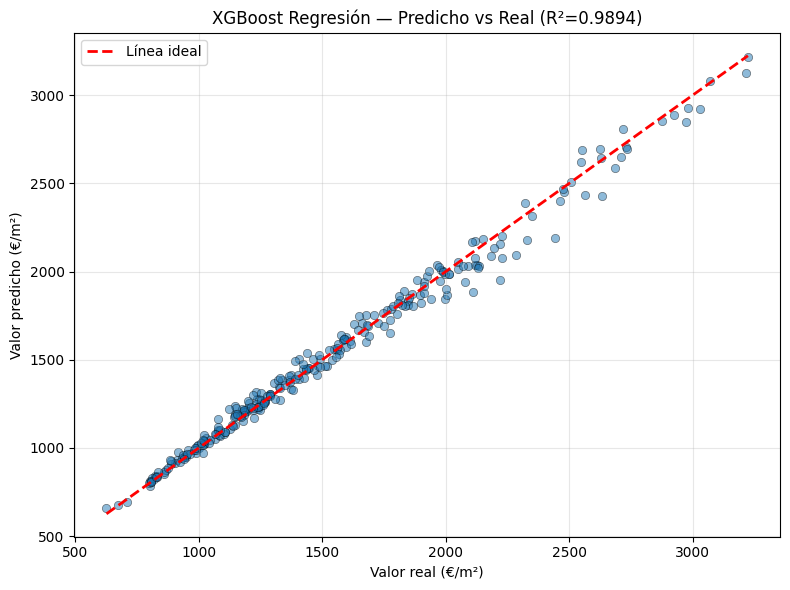

In [15]:
# --- Visualización: Predicho vs Real ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_real, y_pred_reg, alpha=0.5, edgecolors='k', linewidths=0.5)
plt.plot([y_test_reg_real.min(), y_test_reg_real.max()],
         [y_test_reg_real.min(), y_test_reg_real.max()],
         'r--', linewidth=2, label='Línea ideal')
plt.xlabel('Valor real (€/m²)')
plt.ylabel('Valor predicho (€/m²)')
plt.title(f'XGBoost Regresión — Predicho vs Real (R²={r2_xgb:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Conclusiones — XGBoost Regresión

- XGBoost ofrece un rendimiento competitivo frente a los modelos de UT5.
- La comparativa permite ver cómo el Gradient Boosting se posiciona frente a modelos clásicos (lineales, SVM, árboles, ensembles).
- Random Forest y Regresión Polinomial ya obtenían resultados muy buenos en UT5, por lo que XGBoost no necesariamente los supera en todos los casos — depende del dataset y su complejidad.


---
# 2) Aplicar modelo XGBoost — Clasificación

## 2.1) Preprocesado del dataset

Cargamos el dataset Breast Cancer de sklearn (mismo que en UT6). Este dataset es enteramente numérico, por lo que no requiere codificación de variables categóricas.

Para demostrar el manejo de categóricas y la trampa de las variables dummy, nos remitimos al trabajo de UT6 donde se realizaron las demostraciones con datos ficticios. Aquí nos centramos en el preprocesado necesario para el modelado.

In [16]:
# --- Cargar dataset de clasificación ---
cancer = load_breast_cancer()
X_clf = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_clf = pd.Series(cancer.target, name='target')  # 0=maligno, 1=benigno

print(f"Dimensiones: {X_clf.shape}")
print(f"Distribución de clases:\n{y_clf.value_counts()}")
print(f"\nValores missing: {X_clf.isnull().sum().sum()}")


Dimensiones: (569, 30)
Distribución de clases:
target
1    357
0    212
Name: count, dtype: int64

Valores missing: 0


In [17]:
# --- Train/Test split ---
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

# --- Estandarización ---
scaler_clf = StandardScaler()
X_train_clf_sc = pd.DataFrame(
    scaler_clf.fit_transform(X_train_clf),
    columns=X_train_clf.columns, index=X_train_clf.index
)
X_test_clf_sc = pd.DataFrame(
    scaler_clf.transform(X_test_clf),
    columns=X_test_clf.columns, index=X_test_clf.index
)

print(f"Train: {X_train_clf_sc.shape} | Test: {X_test_clf_sc.shape}")
print(f"Proporción clase 1 (benigno) - Train: {y_train_clf.mean():.2f} | Test: {y_test_clf.mean():.2f}")


Train: (455, 30) | Test: (114, 30)
Proporción clase 1 (benigno) - Train: 0.63 | Test: 0.63


## 2.2) Aplicar XGBoostClassifier

In [18]:
# --- Entrenar XGBClassifier ---
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb_clf.fit(X_train_clf_sc, y_train_clf)
print("Modelo XGBClassifier entrenado correctamente.")


Modelo XGBClassifier entrenado correctamente.


## 2.3) Métricas y comparativa con UT6

In [19]:
# --- Predicciones ---
y_pred_clf = xgb_clf.predict(X_test_clf_sc)
y_proba_clf = xgb_clf.predict_proba(X_test_clf_sc)[:, 1]

# --- Métricas ---
acc_xgb = accuracy_score(y_test_clf, y_pred_clf)
prec_xgb = precision_score(y_test_clf, y_pred_clf)
rec_xgb = recall_score(y_test_clf, y_pred_clf)
auc_xgb = roc_auc_score(y_test_clf, y_proba_clf)

print("=== XGBoost Clasificación ===")
print(f"Accuracy:  {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall:    {rec_xgb:.4f}")
print(f"AUC:       {auc_xgb:.4f}")
print(f"\nMatriz de confusión:\n{confusion_matrix(y_test_clf, y_pred_clf)}")
print(f"\n{classification_report(y_test_clf, y_pred_clf, digits=4)}")


=== XGBoost Clasificación ===
Accuracy:  0.9561
Precision: 0.9467
Recall:    0.9861
AUC:       0.9914

Matriz de confusión:
[[38  4]
 [ 1 71]]

              precision    recall  f1-score   support

           0     0.9744    0.9048    0.9383        42
           1     0.9467    0.9861    0.9660        72

    accuracy                         0.9561       114
   macro avg     0.9605    0.9454    0.9521       114
weighted avg     0.9569    0.9561    0.9558       114



In [20]:
# --- Comparativa con modelos de UT6 ---
comparativa_clf = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'KNN (k=5)', 'SVM Lineal', 'SVM RBF',
               'Naive Bayes', 'Decision Tree', 'Random Forest', 'XGBoost (UT9)'],
    'Accuracy': [0.9825, 0.9561, 0.9737, 0.9825, 0.9298, 0.9123, 0.9561, round(acc_xgb, 4)],
    'AUC': [0.9957, 0.9788, 0.9964, 0.9950, 0.9868, 0.9206, 0.9929, round(auc_xgb, 4)]
})

print("\n=== COMPARATIVA CLASIFICACIÓN: UT6 vs XGBoost (UT9) ===")
print(comparativa_clf.to_string(index=False))



=== COMPARATIVA CLASIFICACIÓN: UT6 vs XGBoost (UT9) ===
             Modelo  Accuracy    AUC
Logistic Regression    0.9825 0.9957
          KNN (k=5)    0.9561 0.9788
         SVM Lineal    0.9737 0.9964
            SVM RBF    0.9825 0.9950
        Naive Bayes    0.9298 0.9868
      Decision Tree    0.9123 0.9206
      Random Forest    0.9561 0.9929
      XGBoost (UT9)    0.9561 0.9914


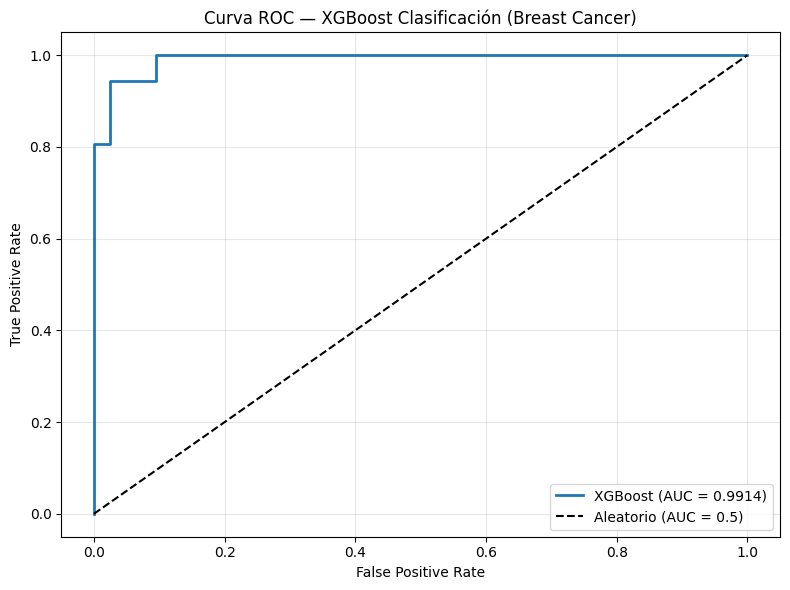

In [21]:
# --- Curva ROC ---
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — XGBoost Clasificación (Breast Cancer)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Conclusiones — XGBoost Clasificación

- XGBoost obtiene resultados competitivos frente a los modelos de UT6.
- En el dataset Breast Cancer, los modelos lineales (LogReg, SVM) ya funcionan muy bien dada la naturaleza del dataset, por lo que la ganancia de XGBoost puede ser marginal.
- La ventaja de XGBoost se manifiesta más en datasets con relaciones no lineales complejas y mayor volumen de datos.


---
# 3) Aplicar PyCaret para AutoML — Clasificación

PyCaret es una librería de AutoML que automatiza el pipeline completo de Machine Learning: preprocesado, entrenamiento, comparación de modelos y evaluación.

Aplicamos PyCaret sobre el dataset de Breast Cancer para comparar automáticamente múltiples modelos y seleccionar el mejor.

In [22]:
# --- Preparar datos para PyCaret ---
from pycaret.classification import setup, compare_models, evaluate_model, predict_model, pull, plot_model

# PyCaret necesita un DataFrame con features + target juntos
df_pycaret = pd.concat([X_clf, y_clf], axis=1)
print(f"DataFrame para PyCaret: {df_pycaret.shape}")
df_pycaret.head()


DataFrame para PyCaret: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [23]:
# --- Setup de PyCaret ---
# PyCaret se encarga automáticamente del preprocesado (escalado, split, etc.)
clf_setup = setup(
    data=df_pycaret,
    target='target',
    train_size=0.8,
    session_id=RANDOM_STATE,  # Equivalente a random_state
    fold=5,
    normalize=True,
    verbose=False
)


In [24]:
# --- Comparar modelos automáticamente ---
# PyCaret entrena múltiples modelos y los ordena por Accuracy
best_model = compare_models(sort="Accuracy")
best_model


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9802,0.9935,0.9895,0.9797,0.9843,0.9575,0.9583,0.5680
et,Extra Trees Classifier,0.9714,0.9923,0.9754,0.9794,0.9772,0.9389,0.9395,0.0260
lightgbm,Light Gradient Boosting Machine,0.9714,0.9897,0.9825,0.9726,0.9774,0.9385,0.9390,0.1700
ada,Ada Boost Classifier,0.9692,0.9872,0.9825,0.9696,0.9758,0.9336,0.9345,0.0240
xgboost,Extreme Gradient Boosting,0.9692,0.9899,0.9825,0.9693,0.9757,0.9337,0.9342,0.0160
knn,K Neighbors Classifier,0.9670,0.9891,0.9825,0.9660,0.9740,0.9290,0.9297,0.2400
svm,SVM - Linear Kernel,0.9670,0.9852,0.9754,0.9729,0.9738,0.9294,0.9306,0.1980
ridge,Ridge Classifier,0.9670,0.9921,0.9965,0.9539,0.9745,0.9280,0.9308,0.0100
lda,Linear Discriminant Analysis,0.9648,0.9884,0.9965,0.9506,0.9728,0.9232,0.9261,0.0080
qda,Quadratic Discriminant Analysis,0.9582,0.9893,0.9649,0.9689,0.9667,0.9107,0.9114,0.0080


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [25]:
# --- Métricas del mejor modelo ---
results_table = pull()
print("\nResultados de compare_models():")
results_table



Resultados de compare_models():


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9802,0.9935,0.9895,0.9797,0.9843,0.9575,0.9583,0.568
et,Extra Trees Classifier,0.9714,0.9923,0.9754,0.9794,0.9772,0.9389,0.9395,0.026
lightgbm,Light Gradient Boosting Machine,0.9714,0.9897,0.9825,0.9726,0.9774,0.9385,0.9390,0.170
ada,Ada Boost Classifier,0.9692,0.9872,0.9825,0.9696,0.9758,0.9336,0.9345,0.024
xgboost,Extreme Gradient Boosting,0.9692,0.9899,0.9825,0.9693,0.9757,0.9337,0.9342,0.016
knn,K Neighbors Classifier,0.9670,0.9891,0.9825,0.9660,0.9740,0.9290,0.9297,0.240
svm,SVM - Linear Kernel,0.9670,0.9852,0.9754,0.9729,0.9738,0.9294,0.9306,0.198
ridge,Ridge Classifier,0.9670,0.9921,0.9965,0.9539,0.9745,0.9280,0.9308,0.010
lda,Linear Discriminant Analysis,0.9648,0.9884,0.9965,0.9506,0.9728,0.9232,0.9261,0.008
qda,Quadratic Discriminant Analysis,0.9582,0.9893,0.9649,0.9689,0.9667,0.9107,0.9114,0.008


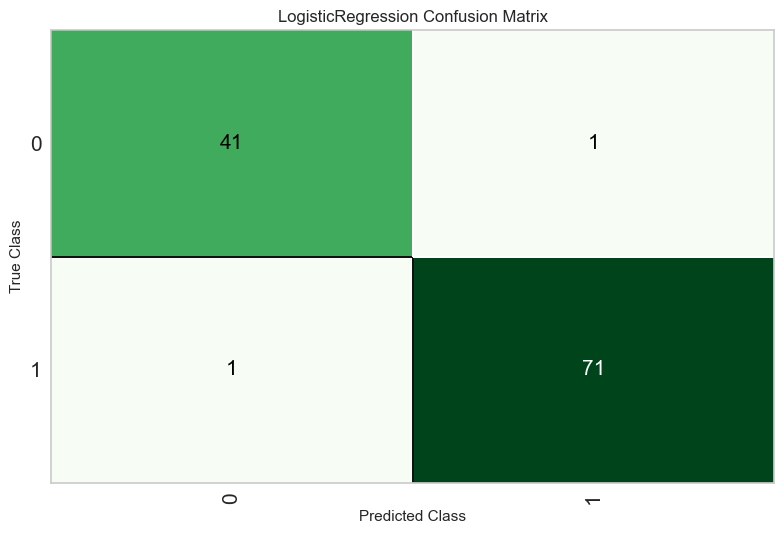

In [26]:
# --- Matriz de confusión del mejor modelo ---
plot_model(best_model, plot="confusion_matrix")


In [27]:
# --- Predicciones sobre el hold-out ---
pred_holdout = predict_model(best_model)
print(f"Predicciones sobre hold-out: {pred_holdout.shape}")
pred_holdout.head()


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623,0.9623


Predicciones sobre hold-out: (114, 33)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,prediction_label,prediction_score
256,19.549999,28.770000,133.600006,1207.000000,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,1926.000000,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050,0,0,1.0000
428,11.130000,16.620001,70.470001,381.100006,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,421.100006,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083,1,1,1.0000
501,13.820000,24.490000,92.330002,595.900024,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,788.000000,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830,0,0,0.9936
363,16.500000,18.290001,106.599998,838.099976,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,1009.000000,0.1338,0.16790,0.1663,0.09123,0.2394,0.06469,1,1,0.5335
564,21.559999,22.389999,142.000000,1479.000000,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,2027.000000,0.1410,0.21130,0.4107,0.22160,0.2060,0.07115,0,0,1.0000


### Conclusiones — PyCaret AutoML

- PyCaret permite comparar decenas de modelos en una sola línea de código (`compare_models()`).
- El modelo seleccionado automáticamente se puede comparar con nuestros resultados manuales de UT6 y con el XGBoost entrenado en el apartado anterior.
- La ventaja principal de AutoML no es necesariamente obtener mejor rendimiento, sino **ahorrar tiempo** en la exploración inicial de modelos y encontrar un buen punto de partida.
- En datasets bien conocidos como Breast Cancer, los modelos clásicos suelen funcionar igual de bien, por lo que AutoML confirma lo que ya sabíamos: los modelos lineales y los ensembles son excelentes para este problema.


---
# 4) Aplicar valores SHAP — Explicabilidad del modelo

SHAP (SHapley Additive exPlanations) es un enfoque basado en la teoría de juegos para explicar las predicciones de cualquier modelo de ML. Los valores SHAP representan la **contribución de cada feature** a la predicción de cada instancia.

Aplicamos SHAP sobre el modelo XGBClassifier entrenado en el apartado 2, utilizando el dataset Breast Cancer.

## 4.1) Preprocesado

Reutilizamos los datos ya preprocesados del apartado 2 (`X_train_clf_sc`, `X_test_clf_sc`, `y_test_clf` y el modelo `xgb_clf`).

In [28]:
# Crear el explicador SHAP para modelos basados en árboles
explainer = shap.TreeExplainer(xgb_clf)

# Calcular valores SHAP para el conjunto de test
shap_values = explainer.shap_values(X_test_clf_sc)

print(f"Forma de shap_values: {shap_values.shape}")
print(f"  - {shap_values.shape[0]} observaciones del test")
print(f"  - {shap_values.shape[1]} features")


Forma de shap_values: (114, 30)
  - 114 observaciones del test
  - 30 features


## 4.2) Explicar una única predicción

Seleccionamos una instancia del conjunto de test y mostramos cómo cada feature contribuye a su predicción.

In [29]:
# --- Seleccionar una instancia para explicar ---
idx = 0  # Primera instancia del test
pred_label = y_pred_clf[idx]
pred_proba = y_proba_clf[idx]
real_label = y_test_clf.iloc[idx]

print(f"Instancia {idx}:")
print(f"  Clase real:     {real_label} ({'benigno' if real_label == 1 else 'maligno'})")
print(f"  Clase predicha: {pred_label} ({'benigno' if pred_label == 1 else 'maligno'})")
print(f"  Probabilidad:   {pred_proba:.4f}")


Instancia 0:
  Clase real:     0 (maligno)
  Clase predicha: 0 (maligno)
  Probabilidad:   0.0011


### Gráfico de fuerza (Force Plot)

El force plot muestra qué features empujan la predicción hacia arriba (clase positiva) o hacia abajo (clase negativa) para una instancia concreta.

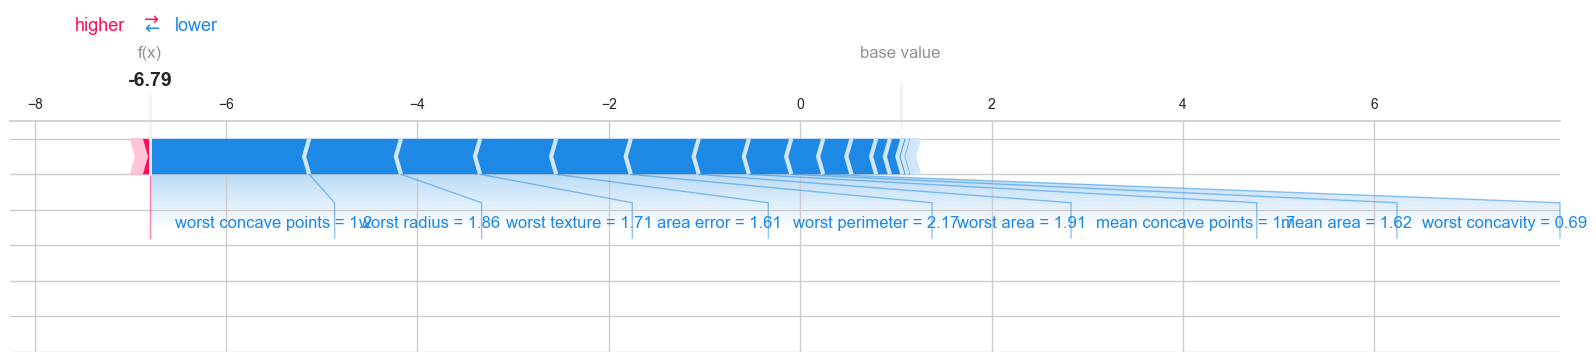

<Figure size 800x550 with 0 Axes>

In [34]:
### como me salen los valores del gráfico muy apiñados los creo con un formato más visible
# --- Force Plot para una instancia ---
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_clf_sc.iloc[idx].round(2),  # Redondear a 2 decimales
    matplotlib=True,
    figsize=(20, 3)  # Más ancho para que respire
)
plt.tight_layout()
plt.show()


El gráfico de fuerza muestra:
- **En rojo:** features que contribuyen a clasificar como maligno (clase 0).
- **En azul:** features que contribuyen a clasificar como benigno (clase 1).
- El **valor base** (expected value) es la predicción media del modelo sin información de features.
- La **predicción final** es el resultado de sumar las contribuciones de todas las features al valor base.

## 4.3) Gráficos de dependencia (Dependence Plots)

Los gráficos de dependencia muestran cómo el valor de una feature afecta a su contribución SHAP. Permiten identificar relaciones no lineales entre features y la predicción.

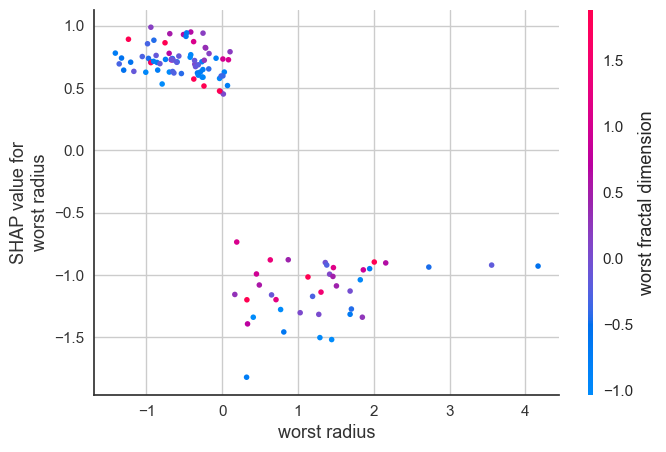

In [35]:
# --- Dependence plot: worst radius ---
shap.dependence_plot('worst radius', shap_values, X_test_clf_sc)


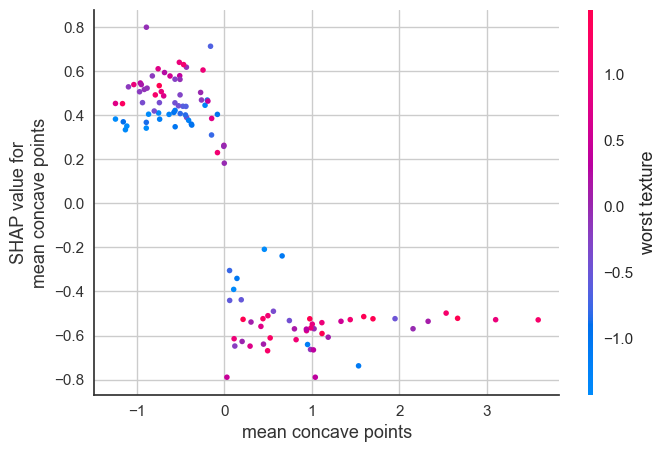

In [36]:
# --- Dependence plot: mean concave points ---
shap.dependence_plot('mean concave points', shap_values, X_test_clf_sc)


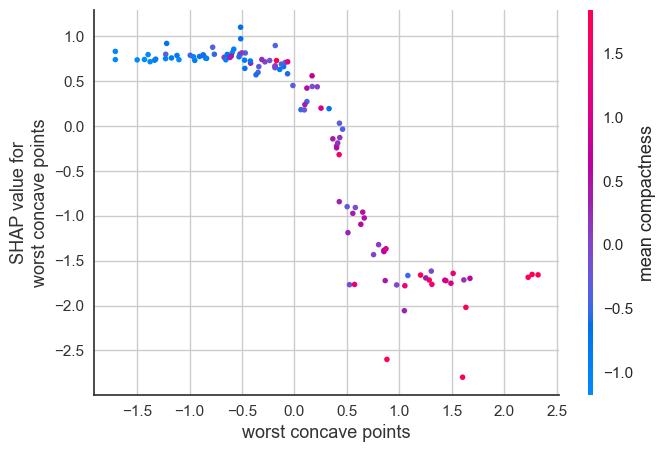

In [37]:
# --- Dependence plot: worst concave points ---
shap.dependence_plot('worst concave points', shap_values, X_test_clf_sc)


### Interpretación de los gráficos de dependencia

- **worst radius:** Valores altos de worst radius tienden a tener contribuciones SHAP negativas (empujan hacia clase 0 = maligno), lo cual tiene sentido clínico: tumores más grandes son más propensos a ser malignos.
- **mean concave points:** Un mayor número de puntos cóncavos en el contorno del tumor está asociado con malignidad, lo que se refleja en contribuciones SHAP negativas para valores altos.
- **worst concave points:** Similar al anterior, refuerza la importancia de la concavidad como indicador de malignidad.

## 4.4) Explicar el dataset completo — Summary Plot

El summary plot muestra la importancia de cada feature para el modelo completo, combinando la magnitud de los valores SHAP con la distribución de los datos.

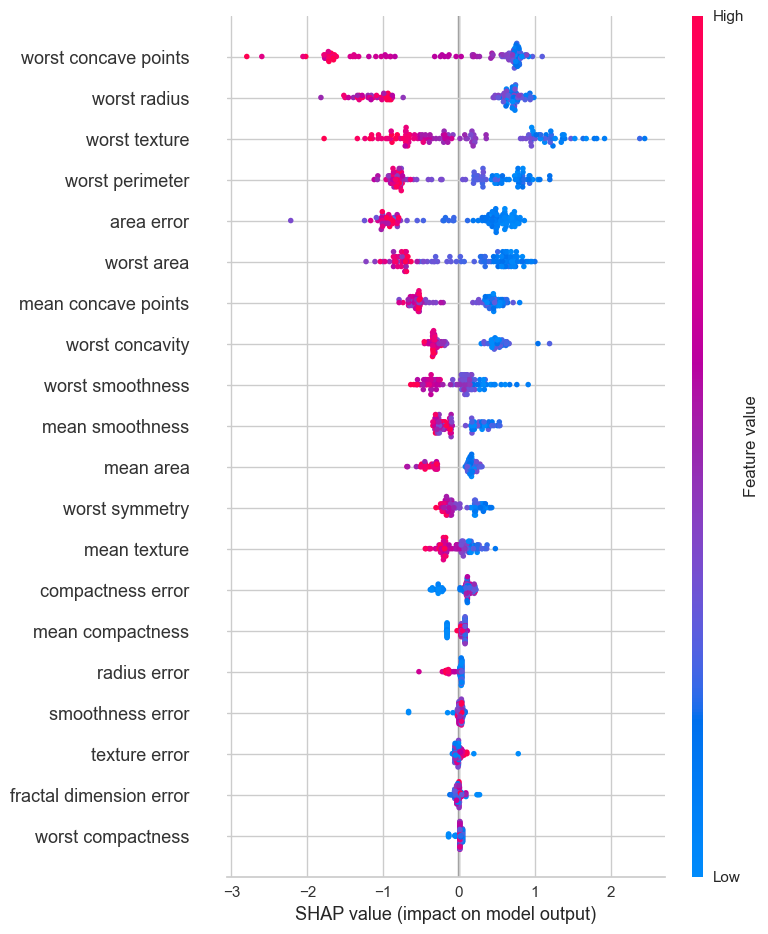

In [38]:
# --- Summary Plot (importancia global) ---
shap.summary_plot(shap_values, X_test_clf_sc)


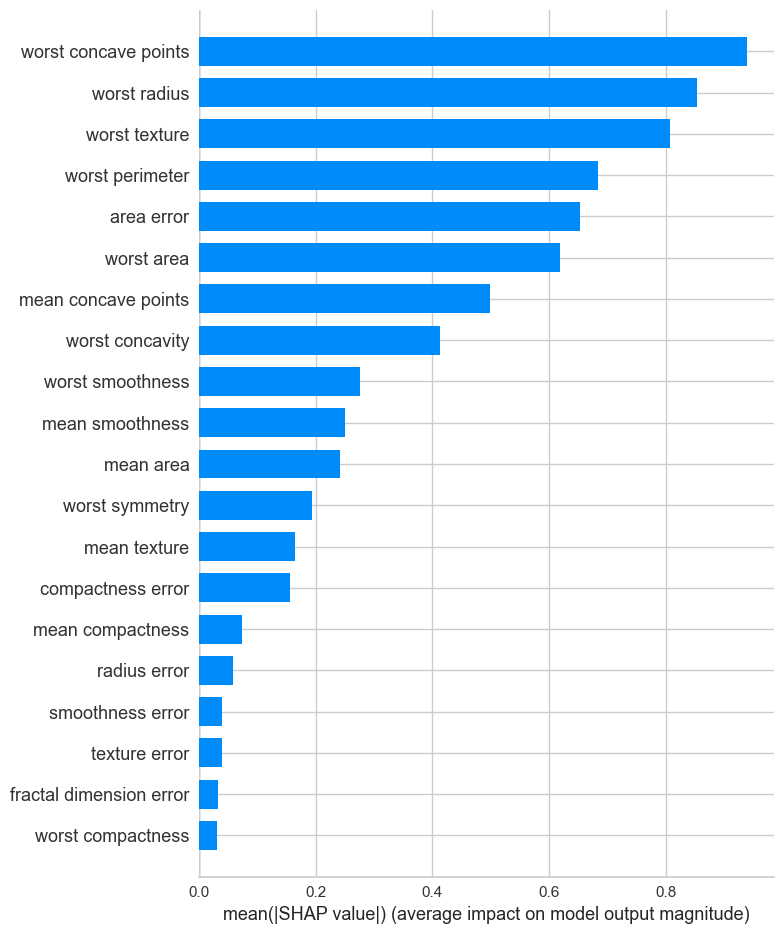

In [39]:
# --- Summary Plot en formato de barras ---
shap.summary_plot(shap_values, X_test_clf_sc, plot_type="bar")


### Conclusiones — SHAP

**Explicación individual:**
- Los force plots permiten entender **por qué** el modelo toma una decisión concreta para cada paciente. Esto es fundamental en contextos médicos donde las predicciones deben ser explicables.

**Explicación por feature:**
- Los dependence plots revelan relaciones no lineales entre features y predicciones. Las features relacionadas con el tamaño y la concavidad del tumor son las más influyentes.

**Explicación global:**
- El summary plot confirma que las features más importantes para el modelo son `worst radius`, `mean concave points`, `worst concave points` y `worst perimeter` — todas relacionadas con el tamaño y la forma del tumor.
- Esto es coherente con el conocimiento médico: tumores más grandes y con bordes irregulares tienen mayor probabilidad de ser malignos.

**Valor de SHAP:**
- SHAP transforma un modelo "caja negra" como XGBoost en un modelo interpretable, sin sacrificar rendimiento. Esto es esencial para la adopción de ML en entornos donde la explicabilidad es un requisito (medicina, finanzas, regulación).


---
# 5) EXTRA: Weights & Biases (WandB) — Experiment Tracking

WandB (Weights & Biases) es una plataforma de MLOps que permite **registrar, visualizar y comparar experimentos** de Machine Learning de forma centralizada.

En este apartado, logueamos las métricas de todos los modelos entrenados en este notebook en un proyecto de WandB, lo que permite:
- Comparar modelos visualmente en un dashboard interactivo.
- Mantener un registro histórico de experimentos.
- Facilitar la colaboración en equipos de datos.

> **Nota:** Para ejecutar esta sección es necesario tener una cuenta gratuita en [wandb.ai](https://wandb.ai) y autenticarse con `wandb login`.

In [ ]:
# --- Configuración de WandB ---
# Autenticación: ejecutar wandb.login() e introducir la API key cuando se solicite.
# La API key se obtiene en https://wandb.ai/authorize
# NOTA: No incluir la API key directamente en el código para evitar exponerla públicamente.

wandb.login()
print("WandB autenticado correctamente.")


WandB autenticado correctamente.


In [ ]:
# --- Inicializar proyecto WandB ---

wandb.init(project="UT9-AutoML", name="XGBoost-Regresion", finish_previous=True)
wandb.log({
    "modelo": "XGBoost Regressor",
    "dataset": "Vivienda España",
    "RMSE": round(rmse_xgb, 2),
    "R2": round(r2_xgb, 4),
})
wandb.finish()

wandb.init(project="UT9-AutoML", name="XGBoost-Clasificacion", finish_previous=True)
wandb.log({
    "modelo": "XGBoost Classifier",
    "dataset": "Breast Cancer",
    "Accuracy": round(acc_xgb, 4),
    "Precision": round(prec_xgb, 4),
    "Recall": round(rec_xgb, 4),
    "AUC": round(auc_xgb, 4),
})
wandb.finish()


wandb: WARNING Using a boolean value for 'reinit' deprecated (fixed). Use 'return_previous' or 'finish_previous' instead.


R2,▁
RMSE,▁
R2,0.9894
RMSE,56.48
dataset,Vivienda España
modelo,XGBoost Regressor


AUC,▁
Accuracy,▁
Precision,▁
Recall,▁
AUC,0.9914
Accuracy,0.9561
Precision,0.9467
Recall,0.9861
dataset,Breast Cancer
modelo,XGBoost Classifier


Código WandB preparado. Descomentar tras autenticarse con wandb.login().


### Uso de WandB en la práctica

El código anterior registra cada experimento como un "run" dentro del proyecto `UT9-AutoML`. Una vez ejecutado, en el dashboard de WandB se puede:

1. **Comparar métricas** de todos los runs en una tabla interactiva.
2. **Visualizar gráficos** de evolución de métricas (útil cuando se entrenan modelos iterativamente).
3. **Exportar resultados** para informes.

WandB es una herramienta estándar en la industria para el seguimiento de experimentos de ML (experiment tracking), y forma parte del ecosistema de **MLOps** — la disciplina que aplica prácticas de DevOps al ciclo de vida de modelos de Machine Learning.

**¿Por qué es relevante?**
- En un proyecto real, no se entrena un solo modelo: se prueban decenas de configuraciones. Sin una herramienta de tracking, es imposible saber qué se probó, con qué parámetros y qué resultados dio.
- WandB resuelve este problema proporcionando un registro centralizado, versionado y visual de todos los experimentos.


---
# Conclusiones Finales

## Resumen del trabajo

1. **XGBoost** se ha aplicado tanto a regresión (precios de vivienda) como a clasificación (cáncer de mama), obteniendo resultados competitivos frente a los modelos de UT5 y UT6.

2. **PyCaret (AutoML)** ha permitido comparar múltiples modelos de clasificación de forma automatizada, confirmando que los modelos clásicos ya funcionan muy bien en el dataset Breast Cancer.

3. **SHAP** ha proporcionado explicabilidad al modelo XGBoost, revelando que las features más importantes para la clasificación de tumores están relacionadas con el tamaño y la forma (concavidad) — coherente con el conocimiento médico.

4. **WandB** (extra) demuestra cómo las herramientas de MLOps permiten gestionar experimentos de ML de forma profesional y escalable.

## Reflexión

La principal lección de este trabajo es que **el rendimiento del modelo no lo es todo**. XGBoost puede no superar significativamente a modelos más simples en datasets bien comportados, pero su verdadero valor aparece cuando se combina con:
- **Explicabilidad** (SHAP): saber *por qué* el modelo decide lo que decide.
- **Automatización** (PyCaret/AutoML): explorar rápidamente el espacio de modelos.
- **Gestión de experimentos** (WandB): mantener un registro ordenado de lo que se ha probado.

Estas tres dimensiones — rendimiento, explicabilidad y gestión — son las que distinguen un proyecto de ML académico de uno profesional.
